In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

#importing libraries


In [2]:
X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_val   = pd.read_csv("y_val.csv").squeeze()

X_train.shape, X_val.shape, y_train.shape, y_val.shape


#taking the excel spreadsheets and turning it into python readable data
#squeeze to make it a list of ansewers 

((73271, 44), (18318, 44), (73271,), (18318,))

In [3]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Example numeric:", list(num_cols[:5]))
print("Example categorical:", list(cat_cols[:5]))


#seperating the numeric and alphanumeric columns as they require different preprocessing needs 
#examples for confirmation its working 

Numeric cols: 11
Categorical cols: 33
Example numeric: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures']
Example categorical: ['race', 'gender', 'age', 'diag_1', 'diag_2']


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)
#Preprocessing
#for numeric values we run standard Scaler (standardizes column values so one field isnt seen as more important than the other)
#for alphanumeric we run one hot encoding  (one hot encoding takes different possible values to a column and gives it a binary value)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(max_iter=8000))
])

svm_baseline.fit(X_train, y_train)


#creating  pipline that says preprocess the data
#use linear svc


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

pred = svm_baseline.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))


[[8410 1427   34]
 [4413 1952   33]
 [1351  675   23]]
              precision    recall  f1-score   support

           0       0.59      0.85      0.70      9871
           1       0.48      0.31      0.37      6398
           2       0.26      0.01      0.02      2049

    accuracy                           0.57     18318
   macro avg       0.44      0.39      0.36     18318
weighted avg       0.52      0.57      0.51     18318



In [9]:
from sklearn.model_selection import GridSearchCV

svm_balanced = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(
        class_weight="balanced",
        max_iter=8000
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    svm_balanced,
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

best_model = grid.best_estimator_
pred = best_model.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))




Best parameters: {'model__C': 0.01}
[[7519 1892  460]
 [3534 2327  537]
 [1046  707  296]]
              precision    recall  f1-score   support

           0       0.62      0.76      0.68      9871
           1       0.47      0.36      0.41      6398
           2       0.23      0.14      0.18      2049

    accuracy                           0.55     18318
   macro avg       0.44      0.42      0.42     18318
weighted avg       0.53      0.55      0.53     18318



In [8]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm_balanced = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(class_weight="balanced", max_iter=12000))
])

param_grid = {
    "model__C": np.logspace(-4, -1, 10)   # 0.0001 ... 0.1 (10 values)
}

grid2 = GridSearchCV(
    svm_balanced,
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid2.fit(X_train, y_train)

print("Best C:", grid2.best_params_)
print("Best CV macro-F1:", grid2.best_score_)


Best C: {'model__C': np.float64(0.046415888336127774)}
Best CV macro-F1: 0.43408473793412805


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

best_model2 = grid2.best_estimator_
pred2 = best_model2.predict(X_val)

print(confusion_matrix(y_val, pred2))
print(classification_report(y_val, pred2))


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report

svm_balanced = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(class_weight="balanced", max_iter=12000))
])

# Small focused search around 0.01
param_grid_C = {
    "model__C": [0.002, 0.005, 0.01, 0.02, 0.05]
}

grid_C = GridSearchCV(
    svm_balanced,
    param_grid_C,
    scoring="f1_macro",
    cv=3,          # <-- faster than 5
    n_jobs=-1
)

grid_C.fit(X_train, y_train)

print("Best C:", grid_C.best_params_, "CV macro-F1:", grid_C.best_score_)
best_C_model = grid_C.best_estimator_



pred = best_C_model.predict(X_val)
print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))



Best C: {'model__C': 0.02} CV macro-F1: 0.4330390267967788
[[7443 1930  498]
 [3472 2359  567]
 [1028  717  304]]
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      9871
           1       0.47      0.37      0.41      6398
           2       0.22      0.15      0.18      2049

    accuracy                           0.55     18318
   macro avg       0.44      0.42      0.42     18318
weighted avg       0.53      0.55      0.53     18318



In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report
svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(max_iter=12000))
])

param_grid = {
    "model__C": [0.01, 0.02, 0.05],   # keep tight
    "model__class_weight": [
        "balanced",
        {0: 1, 1: 1, 2: 2},
        {0: 1, 1: 1, 2: 3},
        {0: 1, 1: 1, 2: 4},
    ]
}

grid_w = GridSearchCV(
    svm,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

grid_w.fit(X_train, y_train)

print("Best params:", grid_w.best_params_)
print("Best CV macro-F1:", grid_w.best_score_)
best_model = grid_w.best_estimator_


pred = best_model.predict(X_val)
print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))


Best params: {'model__C': 0.02, 'model__class_weight': 'balanced'}
Best CV macro-F1: 0.4330390267967788
[[7443 1930  498]
 [3472 2359  567]
 [1028  717  304]]
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      9871
           1       0.47      0.37      0.41      6398
           2       0.22      0.15      0.18      2049

    accuracy                           0.55     18318
   macro avg       0.44      0.42      0.42     18318
weighted avg       0.53      0.55      0.53     18318



In [12]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

sgd_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SGDClassifier(
        loss="log_loss",        # key change (soft decision boundary)
        class_weight={0:1, 1:1, 2:3},  # push class 2 harder
        alpha=1e-4,             # regularisation (similar role to C)
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

sgd_model.fit(X_train, y_train)

pred = sgd_model.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred))


[[9027  697  147]
 [5040 1142  216]
 [1519  393  137]]
              precision    recall  f1-score   support

           0       0.58      0.91      0.71      9871
           1       0.51      0.18      0.26      6398
           2       0.27      0.07      0.11      2049

    accuracy                           0.56     18318
   macro avg       0.45      0.39      0.36     18318
weighted avg       0.52      0.56      0.49     18318



In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get class probabilities
probs = sgd_model.predict_proba(X_val)

# Manually rebalance decision scores
# Boost minority classes
probs[:, 1] *= 1.5   # class 1 boost
probs[:, 2] *= 2.0   # class 2 stronger boost

# Renormalise (optional but clean)
probs = probs / probs.sum(axis=1, keepdims=True)

# New predictions
pred_adj = np.argmax(probs, axis=1)

print(confusion_matrix(y_val, pred_adj))
print(classification_report(y_val, pred_adj))


[[7629 1586  656]
 [3700 1944  754]
 [1067  570  412]]
              precision    recall  f1-score   support

           0       0.62      0.77      0.69      9871
           1       0.47      0.30      0.37      6398
           2       0.23      0.20      0.21      2049

    accuracy                           0.55     18318
   macro avg       0.44      0.43      0.42     18318
weighted avg       0.52      0.55      0.52     18318



In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

probs = sgd_model.predict_proba(X_val)

# Fine-grained rebalancing
probs[:, 1] *= 1.6   # class 1 (moderate boost)
probs[:, 2] *= 1.9   # class 2 (slightly less aggressive than before)

# Renormalise
probs = probs / probs.sum(axis=1, keepdims=True)

pred_adj = np.argmax(probs, axis=1)

print(confusion_matrix(y_val, pred_adj))
print(classification_report(y_val, pred_adj))


[[7388 1969  514]
 [3504 2311  583]
 [1022  699  328]]
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      9871
           1       0.46      0.36      0.41      6398
           2       0.23      0.16      0.19      2049

    accuracy                           0.55     18318
   macro avg       0.44      0.42      0.42     18318
weighted avg       0.52      0.55      0.53     18318



In [16]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

probs = sgd_model.predict_proba(X_val)

best = (-1, None)  # (macro_f1, (m1, m2))
best_pred = None

m1_list = [1.0, 1.2, 1.4, 1.6, 1.8]   # boost for class 1
m2_list = [1.0, 1.3, 1.6, 1.9, 2.2]   # boost for class 2

for m1 in m1_list:
    for m2 in m2_list:
        p = probs.copy()
        p[:, 1] *= m1
        p[:, 2] *= m2
        p = p / p.sum(axis=1, keepdims=True)
        pred = np.argmax(p, axis=1)

        mf1 = f1_score(y_val, pred, average="macro")
        if mf1 > best[0]:
            best = (mf1, (m1, m2))
            best_pred = pred

print("Best macro-F1:", best[0])
print("Best multipliers (class1, class2):", best[1])
print(confusion_matrix(y_val, best_pred))
print(classification_report(y_val, best_pred))



Best macro-F1: 0.43230077753507673
Best multipliers (class1, class2): (1.8, 2.2)
[[6700 2502  669]
 [2983 2708  707]
 [ 864  796  389]]
              precision    recall  f1-score   support

           0       0.64      0.68      0.66      9871
           1       0.45      0.42      0.44      6398
           2       0.22      0.19      0.20      2049

    accuracy                           0.53     18318
   macro avg       0.44      0.43      0.43     18318
weighted avg       0.52      0.53      0.53     18318



,Pred 0,Pred 1,Pred 2
Actual 0,6700,2502,669
Actual 1,2983,2708,707
Actual 2,864,796,389


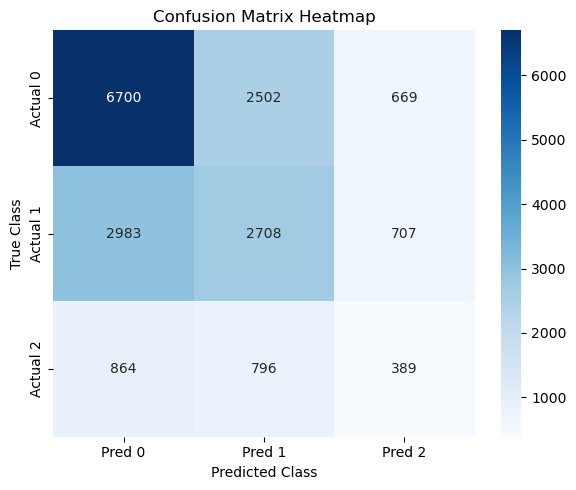

,precision,recall,f1-score,support
0,0.640000,0.680000,0.660000,9871.000000
1,0.450000,0.420000,0.440000,6398.000000
2,0.220000,0.190000,0.200000,2049.000000
accuracy,0.530000,0.530000,0.530000,0.530000
macro avg,0.440000,0.430000,0.430000,18318.000000
weighted avg,0.520000,0.530000,0.530000,18318.000000


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ====== CONFUSION MATRIX ======
cm = confusion_matrix(y_val, best_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Pred 0", "Pred 1", "Pred 2"]
)

display(cm_df.style
        .set_caption("Confusion Matrix")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{
            "selector": "th",
            "props": [("border", "1px solid black")]
        }, {
            "selector": "td",
            "props": [("border", "1px solid black")]
        }])
)

# ====== HEATMAP ======
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

# ====== CLASSIFICATION REPORT TABLE ======
report = classification_report(y_val, best_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)

display(report_df.style
        .set_caption("Classification Report")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{
            "selector": "th",
            "props": [("border", "1px solid black")]
        }, {
            "selector": "td",
            "props": [("border", "1px solid black")]
        }])
)


,Pred 0,Pred 1,Pred 2
Actual 0,6700,2502,669
Actual 1,2983,2708,707
Actual 2,864,796,389


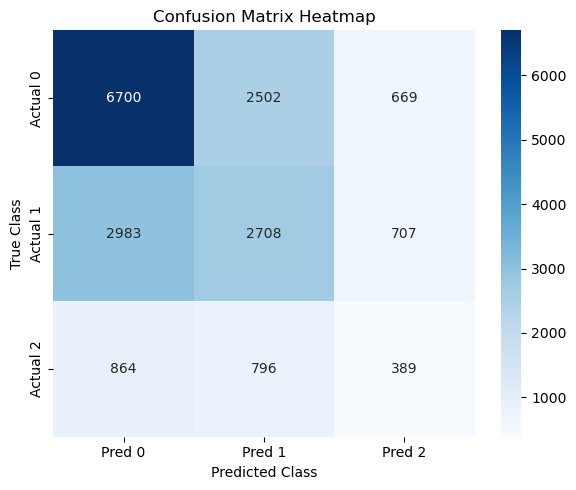

C:\Users\zerub\AppData\Local\Temp\ipykernel_1584\4076475683.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  report_df = report_df.applymap(


,precision,recall,f1-score,support
0,0.64,0.68,0.66,9.9e+03
1,0.45,0.42,0.44,6.4e+03
2,0.22,0.19,0.2,2e+03
accuracy,0.53,0.53,0.53,0.53
macro avg,0.44,0.43,0.43,1.8e+04
weighted avg,0.52,0.53,0.53,1.8e+04


In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====== CONFUSION MATRIX ======
cm = confusion_matrix(y_val, best_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Pred 0", "Pred 1", "Pred 2"]
)

display(cm_df.style
        .set_caption("Confusion Matrix")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("border", "1px solid black")]},
            {"selector": "td", "props": [("border", "1px solid black")]}
        ])
)

# ====== HEATMAP ======
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

# ====== CLASSIFICATION REPORT (2 SIGNIFICANT FIGURES) ======
report = classification_report(y_val, best_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Apply 2 significant figures formatting
report_df = report_df.applymap(
    lambda x: f"{x:.2g}" if isinstance(x, (int, float)) else x
)

display(report_df.style
        .set_caption("Classification Report (2 Significant Figures)")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("border", "1px solid black")]},
            {"selector": "td", "props": [("border", "1px solid black")]}
        ])
)


In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

report = classification_report(y_val, best_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Format metrics to 2 significant figures, keep support as int
for col in report_df.columns:
    if col == "support":
        report_df[col] = report_df[col].astype(int)
    else:
        report_df[col] = report_df[col].apply(
            lambda x: f"{x:.2g}" if isinstance(x, (int, float)) else x
        )

display(
    report_df.style
        .set_caption("Classification Report (2 Significant Figures)")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("border", "1px solid black")]},
            {"selector": "td", "props": [("border", "1px solid black")]}
        ])
)


,precision,recall,f1-score,support
0,0.64,0.68,0.66,9871
1,0.45,0.42,0.44,6398
2,0.22,0.19,0.2,2049
accuracy,0.53,0.53,0.53,0
macro avg,0.44,0.43,0.43,18318
weighted avg,0.52,0.53,0.53,18318
